# FEATURE EXTRACTION

In [1]:
# import libraries
import os
import glob
import pandas as pd
import numpy as np
import math
import pyentrp

import pyentrp

from pyentrp import entropy as ent

import scipy
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import math

import xml.etree.ElementTree as ET
import re

# get relevent folders
curfolder = os.getcwd()
print(curfolder)

flesh_folder = os.path.dirname(curfolder)
motion_processing = flesh_folder + '/Motion_Processing_Folder'

mtfolder = motion_processing + '/TS_movement/'
print(mtfolder)

mtfiles = glob.glob(mtfolder + '*.csv')

demographics = curfolder + "/demographicsProcessed.csv"

which_arm = curfolder + '/which_arm.csv'
which_arm = pd.read_csv(which_arm)



/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Feature_Extraction_Folder
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/


In [3]:
# returns the total movement of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate each side's arm movement seprately
def gesturespace2D(sample, joint, side, movement_type): 
    #get the subdf for where there is only movement for that tier. 
    fileID = sample["fileID"][0]
    total_movement = int(0)
    movement_sample = sample[sample[movement_type] == 'movement']
    # if the movement type is arms, then check whether the left or right arm has movement and output accordingly. 
    if movement_type == 'arms':
        if side == "LEFT_": 
            arm = 'l'
        if side == "RIGHT_":
            arm = 'r'
        # if that specific arm has no movement, return zero
        if not which_arm.loc[which_arm['fileID'] == fileID, 'arms'].isin([arm, 'b']).any():
            return 0
        # if that specific arm does have movement, return the movement
    # if it is no arms, return the movement
    if movement_sample.empty:
        return 0
    else:
        X_std = np.std(movement_sample["X_" + side + joint])
        Y_std = np.std(movement_sample["Y_" + side + joint])
        total_movement = X_std + Y_std # FLAG: hm, should this really be a sumation or rather squared suM??
        return total_movement


# returns the total entropy of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate each side's arm movement seprately
def entropyts2D(sample, joint, side, movement_type):
    fileID = sample["fileID"][0]
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_type == 'arms':
        if side == "LEFT_": 
            arm = 'l'
        if side == "RIGHT_":
            arm = 'r'
        # if that specific arm has no movement, return zero
        if not which_arm.loc[which_arm['fileID'] == fileID, 'arms'].isin([arm, 'b']).any():
            return 0
        # if that specific arm does have movement, return the movement
    if movement_sample.empty:
        return 0
    else:
        speed_ts = (movement_sample[side + joint + "_speed2D"]).values
        sample_entropy = ent.sample_entropy(speed_ts, 1)
        return sample_entropy
    
# returns the total entropy of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate arm movement using the combined timeseries
def entropyts2Daggregated(sample, joint, movement_type):
    fileID = sample["fileID"][0]
    movement_sample = sample[sample[movement_type] == "movement"]
        # if that specific arm does have movement, return the movement
    if movement_sample.empty:
        return 0
    else:
        speed_ts = (movement_sample[joint + "_speed2D"]).values
        sample_entropy = ent.sample_entropy(speed_ts, 1)
        return sample_entropy


# returns the total temporal variability of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate each side's arm movement seprately
def temporal_variability_function2D(sample, joint, side, movement_type):
    fileID = sample["fileID"][0]
    #get the subdf for where there is only movement for that tier. 
    movement_sample = sample[sample[movement_type] == "movement"]
    # calculate each arm separately if there is arm movement
    if movement_type == 'arms':
        if side == "LEFT_": 
            arm = 'l'
        if side == "RIGHT_":
            arm = 'r'
        # if that specific arm has no movement, return zero
        if not which_arm.loc[which_arm['fileID'] == fileID, 'arms'].isin([arm, 'b']).any():
            return 0
    if movement_sample.empty:
        return 0
    else:
        # find the average speed of the speed time series
        speed_ts = (movement_sample[side + joint + "_speed2D"]).to_numpy()
        avg_height = np.mean(speed_ts)
        # calculate the peaks in the speed timeseries with the average speed as the min peak height.
        peaks, _ = scipy.signal.find_peaks(speed_ts, avg_height)
        # determine if there are more than two peaks
        if len(peaks) > 2:
            diff_in_peaks = np.empty(len(peaks)-1)
            # calulcate all the amounts of time between peaks
            for i in range(len(peaks)-1): 
                current_peak = sample.loc[peaks[i], "time" ]
                next_peak = sample.loc[peaks[i+1], "time" ]
                time_between_peaks = next_peak - current_peak
                diff_in_peaks[i] = time_between_peaks
            # find the standard deviation in peak distance
            temporal_variability= np.std(diff_in_peaks)
            return temporal_variability
        else:
            return 0
        

# returns the total temporal variability of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate arm movement using the combined timeseries
def temporal_variability_function2Daggregated(sample, joint, movement_type):
    fileID = sample["fileID"][0]
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    else:
        # find the average speed of the speed time series
        speed_ts = (movement_sample[joint + "_speed2D"]).to_numpy()
        avg_height = np.mean(speed_ts)
        # calculate the peaks in the speed timeseries with the average speed as the min peak height.
        peaks, _ = scipy.signal.find_peaks(speed_ts, avg_height)
        # determine if there are more than two peaks
        if len(peaks) > 2:
            diff_in_peaks = np.empty(len(peaks)-1)
            # calulcate all the amounts of time between peaks
            for i in range(len(peaks)-1): 
                current_peak = sample.loc[peaks[i], "time" ]
                next_peak = sample.loc[peaks[i+1], "time" ]
                time_between_peaks = next_peak - current_peak
                diff_in_peaks[i] = time_between_peaks
            # find the standard deviation in peak distance
            temporal_variability= np.std(diff_in_peaks)
            return temporal_variability
        else:
            return 0
    
## feature for the bounding box of movement
def get_bbmv(sample, keypoint, movement_type):
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    # get spans in each dimension
    x_span = sample['X_' + keypoint].max() - sample['X_' + keypoint].min()
    y_span = sample['Y_' + keypoint].max() - sample['Y_' + keypoint].min()
    #z_span = df['Z_' + keypoint].max() - df['Z_' + keypoint].min()

    # calculate bbmv
    bbmv = x_span * y_span #* z_span
    print(bbmv)
    return bbmv

# feature for intermittency
def get_intermittency(df, keypoint, movement_type):
    movement_sample = df[df[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    jerk_values = df[keypoint + "_TOTAL_jerk2D"]
    speed_values = df[keypoint + "_TOTAL_speed2D"]
    """Calculate the dimensionless smoothness measure using precomputed smoothed jerk and speed."""
    smoothed_jerk = jerk_values
    speed = speed_values
    
    if not np.all(speed == 0):
        integrated_squared_jerk = np.sum(smoothed_jerk ** 2)
        max_squared_speed = np.max(speed ** 2)
        D3 = len(speed) ** 3
        jerk_dimensionless = integrated_squared_jerk * (D3 / max_squared_speed)
        smoothness = jerk_dimensionless
    else:
        smoothness = np.nan

    return smoothness

#other features to add: 
# we can calculate total time for arms, upper body, lower body, head (for all of the movement types.)
def time(sample, movement_type): 
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    time_start = movement_sample.iloc[0] ['time']
    time_end = movement_sample.iloc[-1]['time']
    total_time = time_end-time_start
    return total_time

#calculates the total time of the whole gesture
def overall_time(sample):
    movement_types = ['arms', 'lower_body', 'upper_body', 'head_mov']
    earliest_time = np.inf
    latest_time = 0
    for movement_type in movement_types:
        movement_sample = sample[sample[movement_type] == "movement"]
        if movement_sample.empty:
            continue
        time_start = movement_sample.iloc[0] ['time']
        time_end = movement_sample.iloc[-1]['time']
        if time_start < earliest_time:
            earliest_time = time_start
        if time_end > latest_time:
            latest_time = time_end
    # calculates the time from the earliest start to the latest end
    overall_time = time_end - time_start
    return overall_time
        

# function to create columns for the mean speed and acceleration of all keypoints: 


In [4]:
## running it on one output_file
featuredf = pd.DataFrame()

# gets the survey information
demographics_read = pd.read_csv(demographics) 

# adds survey columns to the features csv file
columns_to_add = demographics_read.columns
for col in columns_to_add:
    featuredf[col] = pd.NA



## THE CODE BLOCK BELOW IS JUST USED TO TEST MY FUNCTIONS ON ONE FILE

In [ ]:
# creates the dataframe of features
featuredf = pd.DataFrame()

# gets the survey information
demographics_read = pd.read_csv(demographics) 

# adds survey columns to the features csv file
columns_to_add = demographics_read.columns
for col in columns_to_add:
    featuredf[col] = pd.NA
file = "/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/leise_g_ch2_g18_compr.eaf.csv"

count = 0
sample = sample = pd.read_csv(file)
movement_sample = sample[sample['arms'] == "movement"]
featuredf.loc[count, "fileID"] = (sample["fileID"])[0]


# get the chainID and the participantID and generation number
featuredf.loc[count, "chainID"] = sample["participantID"][0]
chainID = featuredf["chainID"][count]
split_string = chainID.split('ch')[1]
split_string = split_string.split('g')
chain_num = split_string[0]
gen_num = split_string[1]
featuredf.loc[count, "generation_number"] = int(gen_num)
featuredf.loc[count, "chain_number"] = int(chain_num)
participantID = (int(chain_num) - 1) * 20 + int(gen_num)
gesture = featuredf.loc[count, 'fileID'].split("_")[0]
gesture_chain = (re.split(r"_g\d+", featuredf.loc[count, 'fileID'])[0])
featuredf.loc[count, "participantID"] = participantID
featuredf.loc[count, "gesture"] = gesture
featuredf.loc[count, "gesture_chain"] = gesture_chain

# get the demographic information from the survey and puts it in correct row in featuredf 
matching_rows = demographics_read[demographics_read["participantID"] == int(participantID)]
if len(matching_rows) > 0:
    demographic_row = matching_rows.iloc[0]
    matching_row = demographics_read[demographics_read["participantID"] == int(participantID)]
    featuredf.loc[count, columns_to_add] = matching_row.iloc[0].values
else:
    print("no matching demographics row" + "for" + str(participantID))

get_bbmv(sample, "LEFT_WRIST", 'arms')

overall_time(sample)


head_points = ['NOSE', 'EYE', 'EAR', 'MOUTH']
upper_body_points = ['SHOULDER', 'HIP']
arms_points = ['ELBOW', 'WRIST', 'PINKY', 'INDEX', 'THUMB']
lower_body_points = ['KNEE', 'ANKLE', 'HEEL', 'FOOT']

# for loop to go through every column and find the columns that cotain the string "speed" or the string "acceleration" 
for col in sample.columns:
    if "speed" not in col and "acceleration" not in col:
        continue
    else:
        if any(word in col for word in head_points):
            movement_type = 'head_mov'
        elif any(word in col for word in upper_body_points):
            movement_type = 'upper_body'
        elif any(word in col for word in arms_points):
            movement_type = 'arms'
        elif any(word in col for word in lower_body_points):
            movement_type = 'lower_body'
        movement_sample = sample[sample[movement_type] == "movement"]
        ## see whether the key point has movement:
        if movement_sample.empty:
            featuredf.loc[count, col + "_mean"] = 0
        else: 
            featuredf.loc[count, col + "_mean"] = movement_sample[col].mean()

# Main For Loop For Feature Extraction

In [7]:
count = 0
nijmegen_gestures  = ['koud', 'langzaam', 'nijmegen_nijmegen_rennen', 'onweer', 'stil']
head_points = ['NOSE', 'EYE', 'EAR', 'MOUTH']
upper_body_points = ['SHOULDER', 'HIP']
arms_points = ['ELBOW', 'WRIST', 'PINKY', 'INDEX', 'THUMB']
lower_body_points = ['KNEE', 'ANKLE', 'HEEL', 'FOOT']
# Loop through all files and extract all gesture features
for file in mtfiles:
    print(file)
    sample = pd.read_csv(file)
    fileID = (sample["fileID"])[0]
    # get the fileID 
    featuredf.loc[count, "fileID"] = (sample["fileID"])[0]

    # get the chainID and the participantID and generation number
    ## need to revise this so that it adds a nijmegen vs lndw column because there are repeat chains and participant ids.
    featuredf.loc[count, "chainID"] = sample["participantID"][0]
    chainID = featuredf["chainID"][count]
    split_string = chainID.split('ch')[1]
    split_string = split_string.split('g')
    chain_num = split_string[0]
    gen_num = split_string[1]
    featuredf.loc[count, "generation_number"] = int(gen_num)
    featuredf.loc[count, "chain_number"] = int(chain_num)
    participantID = (int(chain_num) - 1) * 20 + int(gen_num)
    gesture = featuredf.loc[count, 'fileID'].split("_")[0]
    gesture_chain = (re.split(r"_g\d+", featuredf.loc[count, 'fileID'])[0])
    featuredf.loc[count, "participantID"] = participantID
    featuredf.loc[count, "gesture"] = gesture
    featuredf.loc[count, "gesture_chain"] = gesture_chain

    if any(word in fileID for word in nijmegen_gestures):
        participantID = 'n' + str(participantID)
        featuredf.loc[count, 'event'] = 'nijmegen'
    else: 
        featuredf.loc[count, 'event'] = 'lndw'

    if featuredf.loc[count, 'event'] == 'lndw':
    # get the demographic information from the survey and puts it in correct row in featuredf 
        matching_rows = demographics_read[demographics_read["participantID"] == int(participantID)]
        if len(matching_rows) > 0:
            demographic_row = matching_rows.iloc[0]
            matching_row = demographics_read[demographics_read["participantID"] == int(participantID)]
            featuredf.loc[count, columns_to_add] = matching_row.iloc[0].values
        else:
            print("no matching demographics row" + "for" + str(participantID))


    ## get the basic statistics:
    for col in sample.columns:
        if "speed" not in col and "acceleration" not in col:
            continue
        else:
            if any(word in col for word in head_points):
                movement_type = 'head_mov'
            elif any(word in col for word in upper_body_points):
                movement_type = 'upper_body'
            elif any(word in col for word in arms_points):
                movement_type = 'arms'
            elif any(word in col for word in lower_body_points):
                movement_type = 'lower_body'
            movement_sample = sample[sample[movement_type] == "movement"]
            ## see whether the key point has movement:
            if movement_sample.empty:
                featuredf.loc[count, col + "_mean"] = 0
            else: 
                #get mean
                featuredf.loc[count, col + "_mean"] = movement_sample[col].mean()
                # get standard deviation
                featuredf.loc[count, col + "_sd"] = movement_sample[col].std()
                # get peaks and find distances
                featuredf.loc[count, col + "_range"] = movement_sample[col].max() - movement_sample[col].min()


    #Get the gesture space measures
    #left arm
    featuredf.loc[count, "left_index_space2D"] = gesturespace2D(sample, "INDEX", "LEFT_", "arms")
    featuredf.loc[count, "left_wrist_space2D"] = gesturespace2D(sample, "WRIST", "LEFT_", "arms")
    featuredf.loc[count, "left_elbow_space2D"] = gesturespace2D(sample, "ELBOW", "LEFT_", "arms") 
    featuredf.loc[count, "total_left_arm_space2D"] = featuredf.loc[count, "left_index_space2D"] + featuredf.loc[count, "left_wrist_space2D"] + featuredf.loc[count, "left_elbow_space2D"]## FLAG: hm, can we discuss this in flesh meeting whether summations of three keypoints is really the whole space - maybe wrist only would be better

    # right arm
    featuredf.loc[count, "right_index_space2D"] = gesturespace2D(sample, "INDEX", "RIGHT_", "arms")
    featuredf.loc[count, "right_wrist_space2D"] = gesturespace2D(sample, "WRIST", "RIGHT_", "arms")
    featuredf.loc[count, "right_elbow_space2D"] = gesturespace2D(sample, "ELBOW", "RIGHT_", "arms")
    featuredf.loc[count, "total_right_arm_space2D"] = featuredf.loc[count, "right_index_space2D"] + featuredf.loc[count, "right_wrist_space2D"] + featuredf.loc[count, "right_elbow_space2D"]

    # left leg
    featuredf.loc[count, "left_ankle_space2D"] = gesturespace2D(sample, "ANKLE", "LEFT_", "lower_body")
    featuredf.loc[count, "left_knee_space2D"] = gesturespace2D(sample, "KNEE", "LEFT_", "lower_body")
    featuredf.loc[count, "left_hip_space2D"] = gesturespace2D(sample, "HIP", "LEFT_", "lower_body")
    featuredf.loc[count, "total_left_leg_space2D"] = featuredf.loc[count, "left_ankle_space2D"] + featuredf.loc[count, "left_knee_space2D"] + featuredf.loc[count, "left_hip_space2D"]

    # right leg
    featuredf.loc[count, "right_ankle_space2D"] = gesturespace2D(sample, "ANKLE", "RIGHT_", "lower_body")
    featuredf.loc[count, "right_knee_space2D"] = gesturespace2D(sample, "KNEE", "RIGHT_", "lower_body")
    featuredf.loc[count, "right_hip_space2D"] = gesturespace2D(sample, "HIP", "RIGHT_", "lower_body")
    featuredf.loc[count, "total_right_leg_space2D"] = featuredf.loc[count, "right_ankle_space2D"] + featuredf.loc[count, "right_knee_space2D"] + featuredf.loc[count, "right_hip_space2D"]

    # head (nose)
    featuredf.loc[count, "nose_space2D"] = gesturespace2D(sample, "NOSE", "", "head_mov")
    featuredf.loc[count, "total_head_space2D"] = featuredf.loc[count, "nose_space2D"]

    # total gesture space
    featuredf.loc[count, "total_gesture_space2D"] = featuredf.loc[count, "total_left_arm_space2D"] + featuredf.loc[count, "total_right_arm_space2D"] + featuredf.loc[count, "total_left_leg_space2D"] + featuredf.loc[count, "total_right_leg_space2D"] + featuredf.loc[count, 'total_head_space2D']

    # get the entropy for wrist, knee, and ankle. 
    #wrist entropy
    featuredf.loc[count, "right_wrist_entropy2D"] = entropyts2D(sample, "WRIST", "RIGHT_", "arms")
    featuredf.loc[count, "left_wrist_entropy2D"] = entropyts2D(sample, "WRIST", "LEFT_", "arms")

    #knees enropy
    featuredf.loc[count, "right_knee_entropy2D"] = entropyts2D(sample, "KNEE", "RIGHT_", "lower_body")
    featuredf.loc[count, "left_knee_entropy2D"] = entropyts2D(sample, "KNEE", "LEFT_", "lower_body")

    #ankle enropy
    featuredf.loc[count, "right_ankle_entropy2D"] = entropyts2D(sample, "ANKLE", "RIGHT_", "lower_body")# FLAG: why both ankle and knee? while for hands we have just wrist
    featuredf.loc[count, "left_ankle_entropy2D"] = entropyts2D(sample, "ANKLE", "LEFT_", "lower_body")

    #total_entropy
    featuredf.loc[count, "total_body_entropy2D"] = featuredf.loc[count, "left_ankle_entropy2D"]+ featuredf.loc[count, "right_ankle_entropy2D"] + featuredf.loc[count, "left_knee_entropy2D"] +featuredf.loc[count, "right_knee_entropy2D"] + featuredf.loc[count, "left_wrist_entropy2D"] + featuredf.loc[count, "right_wrist_entropy2D"]
    
    #total_entropy using aggregated time series
    featuredf.loc[count, "total_body_entropy2Daggregated"] = entropyts2Daggregated(sample, "ARM_TOTAL", "arms")

    # temporal variability
    #wrist
    featuredf.loc[count, "right_wrist_variability2D"] = temporal_variability_function2D(sample, "WRIST", "RIGHT_", "arms")
    featuredf.loc[count, "left_wrist_variability2D"] = temporal_variability_function2D(sample, "WRIST", "LEFT_", "arms")

    #total variability
    featuredf.loc[count, 'total_body_variability2D'] = featuredf.loc[count, "right_wrist_variability2D"] + featuredf.loc[count, "left_wrist_variability2D"]
    
    #total variability using aggreagated time series
    featuredf.loc[count, 'total_body_variability2Daggregated'] = temporal_variability_function2Daggregated(sample, 'ARM_TOTAL', "arms")
    count = count +1


featuredf

/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/Donner_g_ch2_g3_compr.eaf.csv
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/kalt_g_ch1_g0_compr.eaf.csv
no matching demographics rowfor0
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/Donner_g_ch1_g16_compr.eaf.csv


/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/T/ipykernel_46984/2998780890.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  featuredf.loc[count, "total_body_entropy2Daggregated"] = entropyts2Daggregated(sample, "ARM_TOTAL", "arms")
/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/T/ipykernel_46984/2998780890.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  featuredf.loc[count, "right_wrist_variability2D"] = temporal_variability_function2D(sample, "WRIST", "RIGHT_", "arms")
/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/

/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/onweer_g_ch2_g2_compr.eaf.csv
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/kalt_g_ch2_g10_compr.eaf.csv
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/lndw_lndw_rennen_g_ch1_g12_compr.eaf.csv
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/leise_g_ch2_g17_compr.eaf.csv
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/kalt_g_ch2_g6_compr.eaf.csv
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/Donner_g_ch1_g5_compr.eaf.csv
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/onweer_g_ch1_g4_compr.eaf.csv
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Proc

,time,X_NOSE,Y_NOSE,Z_NOSE,X_LEFT_EYE_INNER,Y_LEFT_EYE_INNER,Z_LEFT_EYE_INNER,X_LEFT_EYE,Y_LEFT_EYE,Z_LEFT_EYE,...,RIGHT_SHOULDER_jerk2D,LEFT_INDEX_jerk2D,LEFT_HIP_jerk2D,RIGHT_EAR_jerk2D,RIGHT_PINKY_jerk2D,ARM_TOTAL_jerk2D,arms,lower_body,upper_body,head_mov
0,0.000000,-0.018079,0.360236,-0.377719,-0.003359,0.376283,-0.370206,-0.000799,0.375538,-0.357899,...,1.601770e-06,1.134092e-06,1.334436e-07,1.936920e-06,5.814847e-07,1.721522e-06,no movement,no movement,no movement,no movement
1,16.666667,-0.016273,0.360415,-0.376614,-0.001419,0.376431,-0.369132,0.001127,0.375681,-0.356822,...,-6.020370e-07,-6.642023e-08,-7.364054e-08,-7.370080e-07,-6.740121e-07,8.854022e-07,no movement,no movement,no movement,no movement
2,33.333333,-0.014466,0.360593,-0.375508,0.000520,0.376579,-0.368058,0.003053,0.375824,-0.355745,...,-1.971728e-06,-9.105332e-07,-1.971875e-07,-2.388355e-06,-1.337124e-06,2.371678e-06,no movement,no movement,no movement,no movement
3,50.000000,-0.012660,0.360772,-0.374402,0.002460,0.376727,-0.366984,0.004979,0.375967,-0.354669,...,-2.690224e-06,-1.457139e-06,-2.563333e-07,-3.242554e-06,-1.558534e-06,3.124099e-06,no movement,no movement,no movement,no movement
4,66.666667,-0.010854,0.360950,-0.373297,0.004399,0.376874,-0.365910,0.006905,0.376110,-0.353592,...,-2.920994e-06,-1.760365e-06,-2.681199e-07,-3.501063e-06,-1.471442e-06,3.322263e-06,no movement,no movement,no movement,no movement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1318,21966.666667,-0.012642,0.348729,-0.370366,0.002557,0.365099,-0.363670,0.004664,0.364402,-0.351065,...,-1.251861e-07,-3.139586e-07,-6.436754e-09,-2.313835e-07,-5.663126e-08,2.421312e-07,no movement,no movement,no movement,no movement
1319,21983.333333,-0.011993,0.348597,-0.371826,0.003207,0.364929,-0.365083,0.005317,0.364222,-0.352470,...,-1.919608e-07,-5.266449e-07,-8.088979e-09,-3.373371e-07,2.412909e-07,3.497496e-07,no movement,no movement,no movement,no movement
1320,22000.000000,-0.011344,0.348465,-0.373285,0.003857,0.364758,-0.366496,0.005969,0.364043,-0.353874,...,-2.391835e-07,-7.006650e-07,-8.088386e-09,-4.049985e-07,6.104064e-07,6.116156e-07,no movement,no movement,no movement,no movement
1321,22016.666667,-0.010695,0.348333,-0.374745,0.004507,0.364588,-0.367909,0.006622,0.363863,-0.355279,...,-2.566092e-07,-8.181279e-07,-5.647052e-09,-4.178375e-07,1.050773e-06,9.741846e-07,no movement,no movement,no movement,no movement


# code to plot the features for each chain

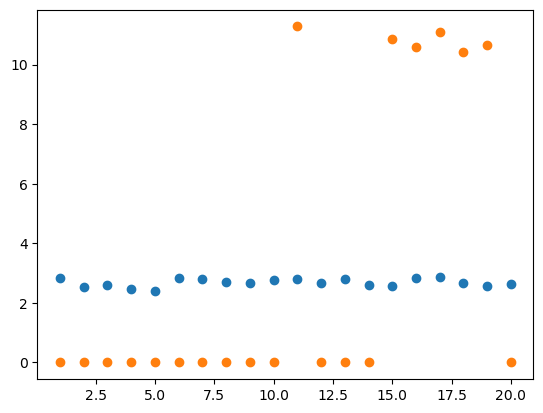

In [10]:
samplechainD = featuredf[featuredf['fileID'].str.contains("onweer_g_ch1")]
plt.plot(samplechainD['generation_number'], samplechainD['total_body_entropy2Daggregated'], marker='o', linestyle='')
plt.plot(samplechainD['generation_number'], samplechainD['total_body_entropy2D'], marker='o', linestyle='')



# Saves the df to the feature extraction file

In [19]:
globals()["feature_extraction"] = featuredf
globals()["feature_extraction"].to_csv(os.path.join(curfolder, f'{"feature_extraction_with2d"}.csv'), index=False)